# Short-Stay Nights — `calendar.csv`

**Source:** `raw data/calendar.csv` (only file used in this notebook)

Each row is one calendar night for one listing, with the `minimum_nights` a
guest must book to reserve that night. A **short-stay night** is defined here
as a night where `minimum_nights < 29` (i.e. below the 29-night threshold,
which separates short-term from long-term/monthly rental rules).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Palette (validated, colorblind-safe) — light-mode chart chrome
BLUE   = "#2a78d6"   # series 1 — short stay
ORANGE = "#eb6834"   # series 2 — long stay
INK       = "#0b0b0b"
INK_MUTED = "#898781"
GRID      = "#e1e0d9"
SURFACE   = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.size": 11,
})

## 1. Load the data

In [2]:
df = pd.read_csv("../raw data/calendar.csv", parse_dates=["date"])
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Rows: 1,185,155  |  Columns: ['listing_id', 'date', 'available', 'minimum_nights', 'maximum_nights']


,listing_id,date,available,minimum_nights,maximum_nights
0,71609,2026-07-02,f,92,1125
1,71609,2026-07-03,t,92,1125
2,71609,2026-07-04,t,92,1125
3,71609,2026-07-05,t,92,1125
4,71609,2026-07-06,t,92,1125


In [3]:
df.dtypes

listing_id                 int64
date              datetime64[us]
available                    str
minimum_nights             int64
maximum_nights             int64
dtype: object

## 2. Flag short-stay nights

A night is a **short stay** when `minimum_nights < 29`.

In [4]:
SHORT_STAY_THRESHOLD = 29

df["is_short_stay"] = df["minimum_nights"] < SHORT_STAY_THRESHOLD

total_nights = len(df)
short_nights = int(df["is_short_stay"].sum())
long_nights = total_nights - short_nights

print(f"Total calendar nights:  {total_nights:,}")
print(f"Short-stay nights (<{SHORT_STAY_THRESHOLD} days): {short_nights:,} ({short_nights/total_nights:.1%})")
print(f"Long-stay nights (>={SHORT_STAY_THRESHOLD} days):  {long_nights:,} ({long_nights/total_nights:.1%})")

Total calendar nights:  1,185,155
Short-stay nights (<29 days): 593,456 (50.1%)
Long-stay nights (>=29 days):  591,699 (49.9%)


## 3. Short vs. long stay nights

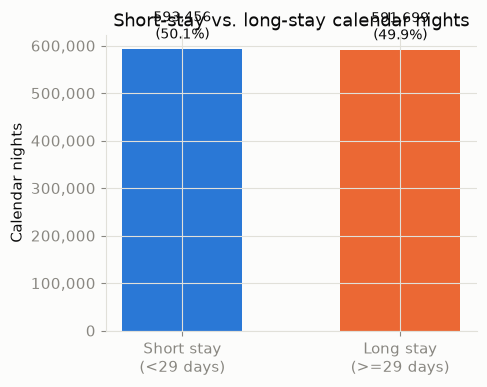

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = [short_nights, long_nights]
labels = [f"Short stay\n(<{SHORT_STAY_THRESHOLD} days)", f"Long stay\n(>={SHORT_STAY_THRESHOLD} days)"]
colors = [BLUE, ORANGE]

bars = ax.bar(labels, counts, color=colors, width=0.55)
for bar, count in zip(bars, counts):
    ax.annotate(f"{count:,}\n({count/total_nights:.1%})",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", color=INK, fontsize=10)

ax.set_ylabel("Calendar nights")
ax.set_title("Short-stay vs. long-stay calendar nights")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 4. Distribution of `minimum_nights`

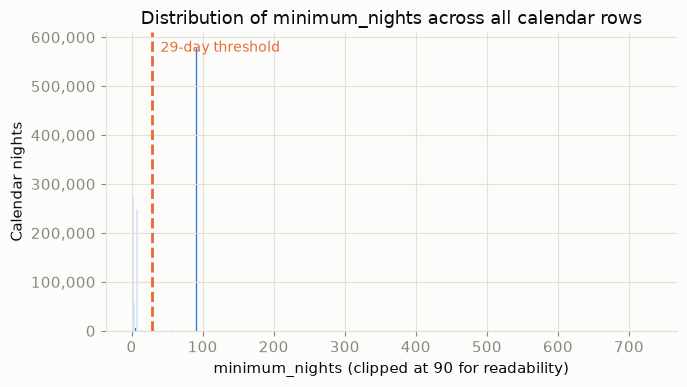

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = list(range(0, 95, 2)) + [df["minimum_nights"].max() + 1]
ax.hist(df["minimum_nights"].clip(upper=90), bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(SHORT_STAY_THRESHOLD, color=ORANGE, linewidth=2, linestyle="--")
ax.annotate(f"{SHORT_STAY_THRESHOLD}-day threshold", xy=(SHORT_STAY_THRESHOLD, ax.get_ylim()[1]),
            xytext=(6, -6), textcoords="offset points", color=ORANGE, fontsize=10, va="top")

ax.set_xlabel("minimum_nights (clipped at 90 for readability)")
ax.set_ylabel("Calendar nights")
ax.set_title("Distribution of minimum_nights across all calendar rows")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. Short-stay nights by listing

Not every listing offers short stays on every date. This groups the flagged
nights by `listing_id` to see how many listings allow short stays, and how
much of each listing's calendar qualifies.

In [7]:
by_listing = (
    df.groupby("listing_id")
      .agg(total_nights=("is_short_stay", "size"),
           short_stay_nights=("is_short_stay", "sum"))
      .assign(pct_short=lambda d: d["short_stay_nights"] / d["total_nights"])
      .sort_values("short_stay_nights", ascending=False)
)

n_listings = len(by_listing)
n_listings_with_short = int((by_listing["short_stay_nights"] > 0).sum())

print(f"Total listings:                         {n_listings:,}")
print(f"Listings with >=1 short-stay night:      {n_listings_with_short:,} ({n_listings_with_short/n_listings:.1%})")
print(f"Listings with ALL nights short-stay:     {int((by_listing['pct_short'] == 1).sum()):,}")
by_listing.head(10)

Total listings:                         3,247
Listings with >=1 short-stay night:      1,633 (50.3%)
Listings with ALL nights short-stay:     1,623


,total_nights,short_stay_nights,pct_short
listing_id,,,
1716877869359547646,365,365,1.00
1315652515073850821,365,365,1.00
50220613,365,365,1.00
49951302,365,365,1.00
1315651915525125863,365,365,1.00
49936029,365,365,1.00
49863259,365,365,1.00
1315651916134063029,365,365,1.00
1315652008053341890,365,365,1.00


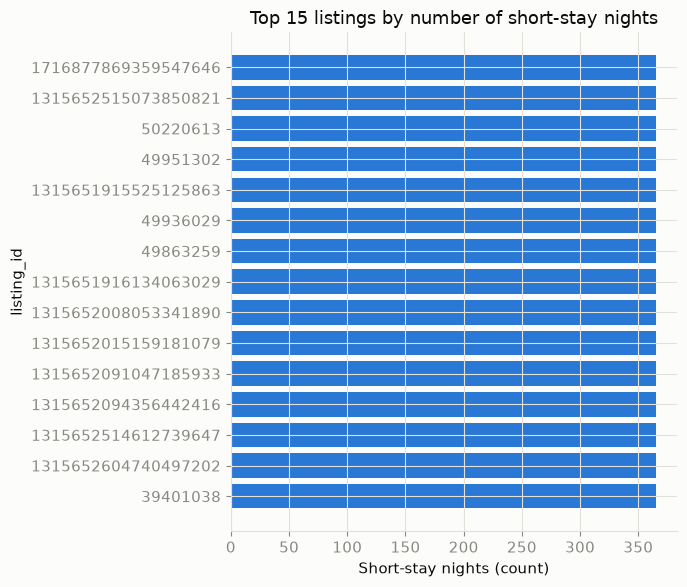

In [8]:
top15 = by_listing.head(15).iloc[::-1]  # reverse for horizontal bar (largest on top)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15.index.astype(str), top15["short_stay_nights"], color=BLUE)
ax.set_xlabel("Short-stay nights (count)")
ax.set_ylabel("listing_id")
ax.set_title("Top 15 listings by number of short-stay nights")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Export the filtered rows

Save just the short-stay calendar rows (`minimum_nights < 29`) to this
`analysis/` folder for downstream use, without touching the original
`raw data/calendar.csv`.

In [9]:
short_stay_df = df[df["is_short_stay"]].drop(columns=["is_short_stay"])
short_stay_df.to_csv("short_stay_nights.csv", index=False)
print(f"Saved {len(short_stay_df):,} short-stay rows to analysis/short_stay_nights.csv")

Saved 593,456 short-stay rows to analysis/short_stay_nights.csv


## Summary

See the printed stats above — the counts are computed live in this notebook,
so re-running any cell keeps this section accurate.
